# Eksperyment: Wpływ Architektury (Warstwy i Neurony) na Wyniki MLP

W tym notatniku zbadano, jak zmiana liczby warstw ukrytych i neuronów wpływa na proces uczenia i ostateczną wydajność modelu MLP w zadaniu klasyfikacji wieloklasowej (5 klas, dane nieliniowe).

Wykorzystujemy najlepszą funkcję aktywacji (GELU) z poprzedniego eksperymentu.

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlp import MLP
from mlp.utils import plot_loss, plot_weight_evolution, plot_decision_boundary, train_test_split, accuracy, mse, plot_predictions,load_dataset

# Konfiguracja bazowa
SEED = 44
np.random.seed(SEED)

# Ustaw ścieżkę do pliku CSV
# Upewnij się, że ten plik jest dostępny (np. w folderze '../lab1_data/Classification/')
CSV_PATH = "../lab1_data/Classification/data.circles.train.1000.csv" 
TASK = "multiclass"
ACTIVATION = "gelu" 
LEARNING_RATE = 0.05
EPOCHS = 500
USE_BIAS = True

# Wczytanie i przygotowanie danych
X, y_raw = load_dataset(CSV_PATH)
y = y_raw - 1
N_FEATURES = X.shape[1]
N_CLASSES = len(np.unique(y))
Y_TARGET = y.reshape(-1, 1) # Używamy Y_TARGET w fit/loss, ale X, y w plotach
print(f"Dane wczytane. Cechy: {N_FEATURES}, Klasy: {N_CLASSES}")
print(f"Przykładowe etykiety: {np.unique(y)}")

Dane wczytane. Cechy: 2, Klasy: 4
Przykładowe etykiety: [0 1 2 3]


## Wizualizacja Danych

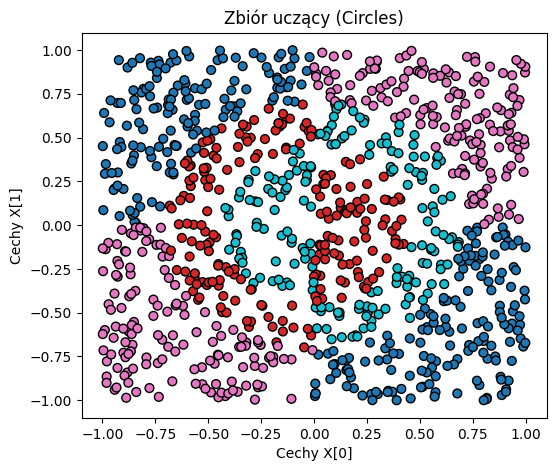

In [117]:
# Wizualizacja zbioru uczącego (zakładamy 2 cechy)
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="tab10", s=40, edgecolors="k")
plt.title("Zbiór uczący (Circles)")
plt.xlabel("Cechy X[0]")
plt.ylabel("Cechy X[1]")
plt.show()

## Konfiguracja i Trening Eksperymentów

In [118]:
# Eksperymentalne architektury do porównania
# Format: { Nazwa: [Rozmiary Warstw] }
ARCHITECTURES = {
    # 1. Architektury Płytkie (Mniej warstw, różna liczba neuronów)
    "Shallow_8": [N_FEATURES, 8, N_CLASSES],      
    "Shallow_16": [N_FEATURES, 16, N_CLASSES],     
    "Shallow_32": [N_FEATURES, 32, N_CLASSES],     
    # 2. Architektury Głębokie (Więcej warstw, podobna liczba neuronów)
    "Deep_8_8": [N_FEATURES, 8, 8, N_CLASSES],     
    "Deep_16_8": [N_FEATURES, 16, 8, N_CLASSES],   
    "Deep_16_16": [N_FEATURES, 16, 16, N_CLASSES],
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.3, seed=SEED)
all_results = {}
print("--- Rozpoczynanie eksperymentów ---")

for name, layer_sizes in ARCHITECTURES.items():
    print(f"\n=== Trening dla architektury: {name} ({layer_sizes}) ===")
    
    # Konfiguracja MLP
    model = MLP(
        layer_sizes=layer_sizes,
        task=TASK,
        activation=ACTIVATION,
        learning_rate=LEARNING_RATE,
        seed=SEED,
    )

    # Trening
    losses, weight_hist = model.fit(
        X_train, y_train, epochs=EPOCHS, verbose=False, one_hot_if_needed=True
    )
    
    # Predykcja i dokładność
    preds = model.predict(X_test)

    if TASK == "regression":
        metric = mse(y_test, preds)
        metric_name = "MSE (TEST)"
    else:
        metric = accuracy(y_test, preds)
        metric_name = "Dokładność (TEST)"

    all_results[name] = {
        "model": model,
        "layer_sizes": layer_sizes,
        "losses": losses,
        "weights": weight_hist,
        "accuracy": metric
    }

    print(f"Końcowa strata (trening): {losses[-1]:.6f} | {metric_name}: {metric:.4f}")

--- Rozpoczynanie eksperymentów ---

=== Trening dla architektury: Shallow_8 ([2, 8, 4]) ===
Końcowa strata (trening): 0.657074 | Dokładność (TEST): 0.2783

=== Trening dla architektury: Shallow_16 ([2, 16, 4]) ===
Końcowa strata (trening): 0.597526 | Dokładność (TEST): 0.2753

=== Trening dla architektury: Shallow_32 ([2, 32, 4]) ===
Końcowa strata (trening): 0.570799 | Dokładność (TEST): 0.2765

=== Trening dla architektury: Deep_8_8 ([2, 8, 8, 4]) ===
Końcowa strata (trening): 0.491783 | Dokładność (TEST): 0.2706

=== Trening dla architektury: Deep_16_8 ([2, 16, 8, 4]) ===
Końcowa strata (trening): 0.573669 | Dokładność (TEST): 0.2776

=== Trening dla architektury: Deep_16_16 ([2, 16, 16, 4]) ===
Końcowa strata (trening): 0.457103 | Dokładność (TEST): 0.2692


## Wizualizacja Wyników

In [119]:
# --- 5.1. Porównanie krzywych błędu (Loss) ---
plt.figure(figsize=(10, 7))
for name, res in all_results.items():
    plt.plot(res["losses"], label=f'{name} (Acc: {res["metric"]:.3f})')

plt.title("Porównanie błędu treningowego dla różnych architektur")
plt.xlabel("Epoka")
plt.ylabel(f"Strata ({all_results[list(ARCHITECTURES.keys())[0]]['model'].loss_fn.__name__})")
plt.grid(True)
plt.legend()
plt.show()

# --- 5.2. Wizualizacja granic decyzyjnych i ewolucji wag ---
for name, res in all_results.items():
    print(f"\n--- Wizualizacja wyników: {name} ---")
    
    # Granice decyzyjne
    plot_decision_boundary(
        res["model"], X, Y_TARGET, 
        title=f"Granica decyzyjna: {name} (Acc: {res['accuracy']:.3f})"
    )
    
    # Ewolucja wag
    plot_weight_evolution(
        res["weights"], 
        title=f"Ewolucja wag: {name}"
    )

KeyError: 'metric'

<Figure size 1000x700 with 0 Axes>